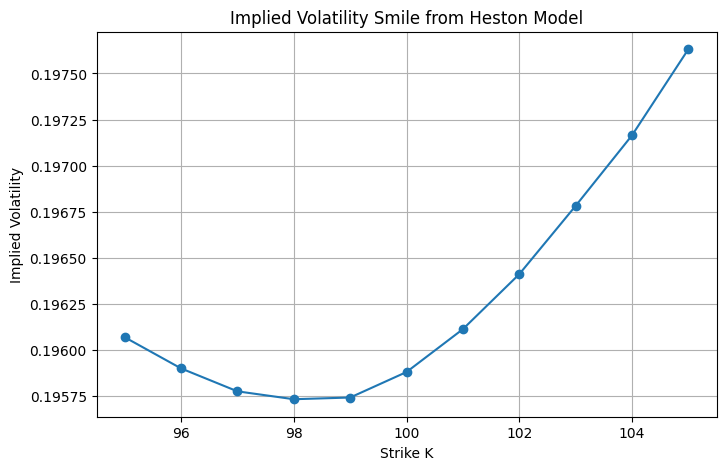

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt

from HestonModel import Heston
from BSpricesEU import BS
from Inversion import IV






#### PARAMETERS #####

S0 = 100
r = 0.02
T = 1


      ## FOR HESTON important to satisfy feller's condition 2kappa*theta\geq sigma^2
Var0=0.05        ### Initial Variance
kappa=1.5         ### Mean reversion 
theta=0.05        ### Long run variance
sigma=0.6    ### vol of vol


rho=-0.0    ### Correlation



n = 2000        # time steps
N = 10000      # number of paths










##### SIMULATION HESTON DYNAMICS #####


S= Heston(S0,Var0,T,r,sigma,kappa,theta,rho,n,N)[0]










##### Heston Call pricing ######


strikes = np.array([95+i for i in range(11)])
L=len(strikes)

def CallHESTON(S,strikes,r,T):

    CallH=np.zeros(11)
    ST=S[n]

    for i in range(0,L):

        K=strikes[i]

        CallH[i]=np.mean(np.exp(-r*T)*np.maximum(ST-K,0))

    return CallH
    
Hes_Call=CallHESTON(S,strikes,r,T)







##### CALIBRATION #######


ImplVol=IV(S0,T,r,strikes,Hes_Call)






##### SIMULATION #####


plt.figure(figsize=(8,5))

plt.plot(strikes, ImplVol, marker='o')

plt.xlabel("Strike K")
plt.ylabel("Implied Volatility")
plt.title("Implied Volatility Smile from Heston Model")

plt.grid(True)

plt.show()

